# This notebook visualizes the Dewpoint results.

In [1]:
import pandas as pd
import numpy as np
import osmnx as ox
import matplotlib.pyplot as plt

# Define your area of interest
place = "Durham, North Carolina, USA"  # or use a bounding box

west, south, east, north = -79.1, 35.8, -78.6, 36.3

G = ox.graph_from_bbox([west, south, east, north], network_type='drive', custom_filter='["highway"~"motorway|trunk"]')
edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

# Let's create the CDD figure

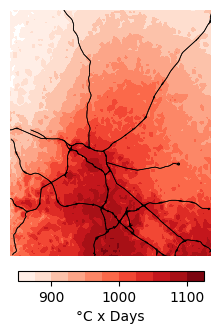

In [14]:
grid = pd.read_csv('../figures/cdd2024.csv', index_col=0)

lon_vals = np.array([float(s) for s in grid.columns.values])
lat_vals = grid.index.values
cdd = grid.values #+ value_grid


plt.figure(figsize=(3, 4))
cp = plt.contourf(lon_vals, lat_vals, cdd, levels=np.arange(850, 1126, 25), cmap='Reds')

# cp = plt.imshow(value_grid,  cmap='Blues')
# plt.colorbar(cp, label='October 8pm Dewpoint (°C)', orientation='horizontal', shrink=0.8, pad=0.05)
edges.plot(ax=plt.gca(), color='black', linewidth=0.5, label='Major Roads')
plt.xlim(lon_vals.min(), lon_vals.max())
plt.ylim(lat_vals.min(), lat_vals.max())
plt.axis('off')
# cp = plt.contourf(lon_vals, lat_vals, value_grid, levels=10, cmap='Reds')
# cp = plt.imshow(value_grid,  cmap='Blues')
cbar = plt.colorbar(cp, label='°C x Days', orientation='horizontal', shrink=0.8, pad=0.05)
cbar.set_ticks(np.arange(900, 1126, 100))
plt.savefig(f'../figures/cdd_2024.pdf', dpi=1000, bbox_inches='tight')

In [12]:
cdd.min()

np.float64(838.1428476666665)

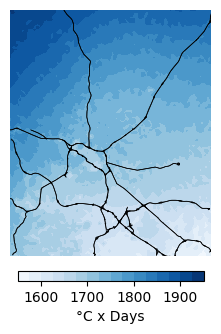

In [28]:
grid = pd.read_csv('../figures/hdd2024.csv', index_col=0)

lon_vals = np.array([float(s) for s in grid.columns.values])
lat_vals = grid.index.values
hdd = grid.values #+ value_grid


plt.figure(figsize=(3, 4))
cp = plt.contourf(lon_vals, lat_vals, hdd, levels=np.arange(1550, 1951, 25), cmap='Blues')
# cp = plt.imshow(value_grid,  cmap='Blues')
# plt.colorbar(cp, label='October 8pm Dewpoint (°C)', orientation='horizontal', shrink=0.8, pad=0.05)
edges.plot(ax=plt.gca(), color='black', linewidth=0.5, label='Major Roads')
plt.xlim(lon_vals.min(), lon_vals.max())
plt.ylim(lat_vals.min(), lat_vals.max())
plt.axis('off')
# cp = plt.contourf(lon_vals, lat_vals, value_grid, levels=10, cmap='Reds')
# cp = plt.imshow(value_grid,  cmap='Blues')
cbar = plt.colorbar(cp, label='°C x Days', orientation='horizontal', shrink=0.8, pad=0.05)
cbar.set_ticks(np.arange(1600, 1951, 100))
plt.savefig(f'../figures/hdd_2024.pdf', dpi=1000, bbox_inches='tight')

In [23]:
hdd.max()

np.float64(1928.5610714037043)

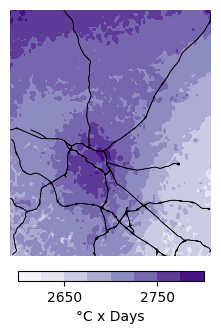

In [32]:
# Now, the total

plt.figure(figsize=(3, 4))
cp = plt.contourf(lon_vals, lat_vals, cdd + hdd, levels=np.arange(2600, 2801, 25), cmap='Purples')
# cp = plt.imshow(value_grid,  cmap='Blues')
# plt.colorbar(cp, label='October 8pm Dewpoint (°C)', orientation='horizontal', shrink=0.8, pad=0.05)
edges.plot(ax=plt.gca(), color='black', linewidth=0.5, label='Major Roads')
plt.xlim(lon_vals.min(), lon_vals.max())
plt.ylim(lat_vals.min(), lat_vals.max())
plt.axis('off')
# cp = plt.contourf(lon_vals, lat_vals, value_grid, levels=10, cmap='Reds')
# cp = plt.imshow(value_grid,  cmap='Blues')
cbar = plt.colorbar(cp, label='°C x Days', orientation='horizontal', shrink=0.8, pad=0.05)
cbar.set_ticks(np.arange(2650, 2801, 100))
plt.savefig(f'../figures/hdd_cdd_2024.pdf', dpi=1000, bbox_inches='tight')

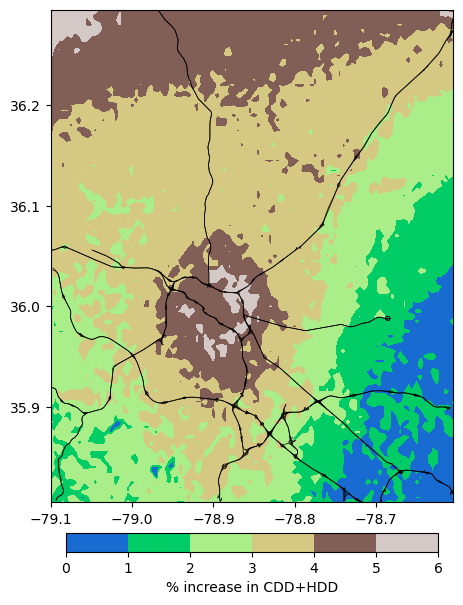

In [ ]:

plt.figure(figsize=(6, 8))
# cp = plt.contourf(lon_vals, lat_vals, value_grid, levels=10, cmap='Blues')
# cp = plt.imshow(value_grid,  cmap='Blues')
# plt.colorbar(cp, label='October 8pm Dewpoint (°C)', orientation='horizontal', shrink=0.8, pad=0.05)
edges.plot(ax=plt.gca(), color='black', linewidth=0.5, label='Major Roads')
plt.xlim(lon_vals.min(), lon_vals.max())
plt.ylim(lat_vals.min(), lat_vals.max())
cp = plt.contourf(lon_vals, lat_vals, 100*(value_grid - value_grid.min())/value_grid.min(), levels=5, cmap='terrain')
# cp = plt.imshow((value_grid - value_grid.min())/value_grid.min() , cmap='Reds', origin='lower')
plt.colorbar(cp, label='% increase in CDD+HDD', orientation='horizontal', shrink=0.8, pad=0.05)
# plt.savefig(f'../figures/cdd_hdd_2024.pdf', dpi=300, bbox_inches='tight')

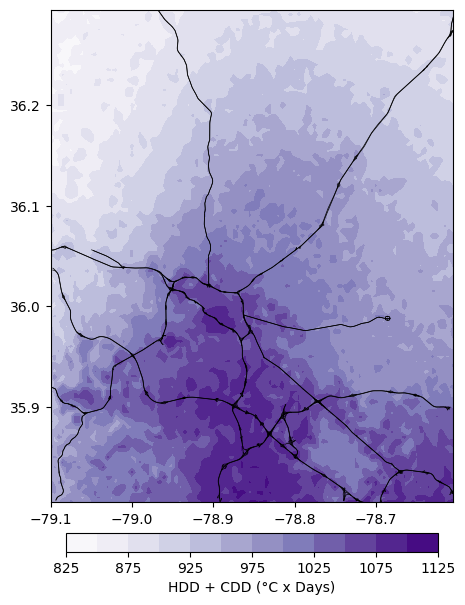

In [8]:
plt.figure(figsize=(6, 8))
cp = plt.contourf(lon_vals, lat_vals, value_grid, levels=10, cmap='Purples')
# cp = plt.imshow(value_grid,  cmap='Blues')
# plt.colorbar(cp, label='October 8pm Dewpoint (°C)', orientation='horizontal', shrink=0.8, pad=0.05)
edges.plot(ax=plt.gca(), color='black', linewidth=0.5, label='Major Roads')
plt.xlim(lon_vals.min(), lon_vals.max())
plt.ylim(lat_vals.min(), lat_vals.max())
# cp = plt.contourf(lon_vals, lat_vals, value_grid, levels=10, cmap='Reds')
# cp = plt.imshow(value_grid,  cmap='Blues')
plt.colorbar(cp, label='HDD + CDD (°C x Days)', orientation='horizontal', shrink=0.8, pad=0.05)
# plt.savefig(f'../figures/hdd_cdd_2024.png', dpi=300, bbox_inches='tight')

# Visualizing the NLCD classes

In [2]:
import pandas as pd
from matplotlib import pyplot as plt

buffer_size = 500
test = pd.read_csv(f'../data/nlcd/pca_test_{buffer_size}m_buffer.csv')

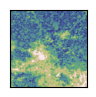

In [8]:
year = 2023
year_2023 = test[test['year'] == year]
lat = year_2023['lat']
lon = year_2023['lon']
mask = test['year'] == year
X_test_pca = year_2023['PC1'].values.reshape(-1, 1)

# Make figure bigger
plt.figure(figsize=(1, 1))
# plt.contourf(lon.values.reshape(100, 100), lat.values.reshape(100, 100), X_test_pca.reshape(100, 100),40,cmap='terrain')#, linestyles='dotted')
plt.imshow(X_test_pca.reshape(100, 100).T, extent=(lon.min(), lon.max(), lat.min(), lat.max()), origin='lower', cmap='gist_earth', alpha=0.8)
plt.xticks([])
plt.yticks([])
# save fig
plt.savefig(f'../final_fig/pca.pdf', dpi=1000, bbox_inches='tight')